# OHCA AED Accessibility Analysis with 2SFCA (Google Colab)

This notebook simulates **200 AED locations in Georgia** and evaluates accessibility for OHCA events using the **Two-Step Floating Catchment Area (2SFCA)** method.

## Workflow
1. Load OHCA points.
2. Load county boundaries and keep Georgia counties only.
3. Simulate 200 random AED points inside Georgia.
4. Compute AED supply ratios (Step 1 of 2SFCA).
5. Compute OHCA accessibility scores (Step 2 of 2SFCA).
6. Summarize and map county-level accessibility, then export outputs.

## 1. Install Packages

In [18]:
!pip -q install geopandas shapely matplotlib contextily

In [19]:
from google.colab import drive
drive.mount('/content/drive/')

ModuleNotFoundError: No module named 'google.colab'

In [20]:
## List all files in COLAB_DATA_DIR = Path('/content/drive/MyDrive/Colab Notebooks/Workshop/data')

In [21]:
import os
COLAB_DATA_DIR = Path('/content/drive/MyDrive/Colab Notebooks/Workshop/data')
for root, dirs, files in os.walk(COLAB_DATA_DIR):
    for file in files:
        print(Path(root) / file)

## 2. Imports and Paths

In [22]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import Point

LOCAL_DATA_DIR = Path('/Users/jenny/Desktop/Workshop/data')
COLAB_DATA_DIR = Path('/content/drive/MyDrive/Colab Notebooks/Workshop/data')
DATA_DIR = COLAB_DATA_DIR if COLAB_DATA_DIR.exists() else LOCAL_DATA_DIR

OHCA_CSV = DATA_DIR/'ohca_connected_data.csv'
COUNTY_SHP = DATA_DIR/'cb_2018_us_county_500k'/'cb_2018_us_county_500k - Copy.shp'

print('OHCA file:', OHCA_CSV)
print('County shapefile:', COUNTY_SHP)

OHCA file: /Users/jenny/Desktop/Workshop/data/ohca_connected_data.csv
County shapefile: /Users/jenny/Desktop/Workshop/data/cb_2018_us_county_500k/cb_2018_us_county_500k - Copy.shp


## 3. Load OHCA Points

In [24]:
lat_col = 'scene_gps_latitude_escene.11'
lon_col = 'scene_gps_longitude_escene.11'

ohca = pd.read_csv(OHCA_CSV)
ohca[lat_col] = pd.to_numeric(ohca[lat_col], errors='coerce')
ohca[lon_col] = pd.to_numeric(ohca[lon_col], errors='coerce')
ohca = ohca.dropna(subset=[lat_col, lon_col]).copy()

ohca_points = gpd.GeoDataFrame(
    ohca,
    geometry=gpd.points_from_xy(ohca[lon_col], ohca[lat_col]),
    crs='EPSG:4326'
)

print('OHCA points:', len(ohca_points))

OHCA points: 6005


## 4. Load Georgia Counties and Keep Georgia OHCA

In [25]:
county = gpd.read_file(COUNTY_SHP).to_crs('EPSG:4326')
ga_counties = county[county['STATEFP'].astype(str) == '13'][['GEOID', 'NAME', 'geometry']].copy()

ohca_ga = gpd.sjoin(
    ohca_points,
    ga_counties,
    how='inner',
    predicate='within'
).drop(columns=['index_right'], errors='ignore')

print('Georgia counties:', len(ga_counties))
print('OHCA points within Georgia counties:', len(ohca_ga))

Georgia counties: 159
OHCA points within Georgia counties: 5963


## 5. Simulate 200 AED Points in Georgia

This uses uniform random sampling inside the Georgia polygon extent and retains only points that fall within Georgia.

In [26]:
rng = np.random.default_rng(42)
target_n = 200

ga_polygon = ga_counties.unary_union
minx, miny, maxx, maxy = ga_polygon.bounds

aed_points = []
while len(aed_points) < target_n:
    xs = rng.uniform(minx, maxx, size=1000)
    ys = rng.uniform(miny, maxy, size=1000)
    for x, y in zip(xs, ys):
        p = Point(x, y)
        if ga_polygon.covers(p):
            aed_points.append(p)
            if len(aed_points) >= target_n:
                break

aed_gdf = gpd.GeoDataFrame(
    {'aed_id': [f'AED_{i+1:03d}' for i in range(target_n)]},
    geometry=aed_points,
    crs='EPSG:4326'
)

print('Simulated AED points:', len(aed_gdf))
aed_gdf.head()

Simulated AED points: 200


/var/folders/l3/bvy4b09s5t50fps32_nlnb0h0000gn/T/ipykernel_69992/3409084823.py:4: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  ga_polygon = ga_counties.unary_union


,aed_id,geometry
0,AED_001,POINT (-83.51372 32.48547)
1,AED_002,POINT (-81.51357 30.95691)
2,AED_003,POINT (-82.2819 31.06507)
3,AED_004,POINT (-85.15637 33.29342)
4,AED_005,POINT (-81.85923 31.83963)


## 6. Map Georgia Counties, OHCA, and Simulated AEDs

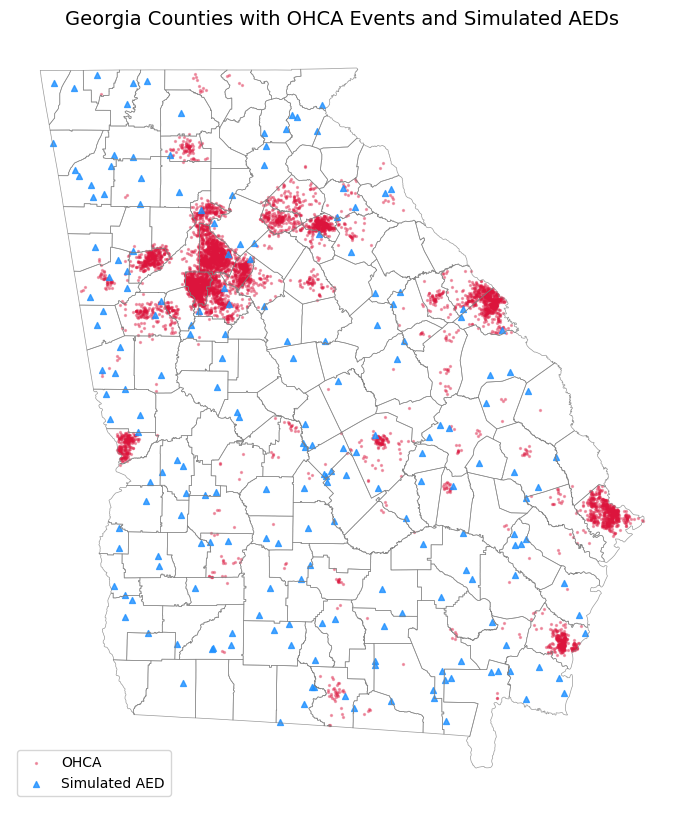

In [27]:
fig, ax = plt.subplots(figsize=(10, 10))
ga_counties.boundary.plot(ax=ax, linewidth=0.5, color='gray', alpha=0.8)
ohca_ga.plot(ax=ax, markersize=2, color='crimson', alpha=0.35, label='OHCA')
aed_gdf.plot(ax=ax, markersize=18, color='dodgerblue', alpha=0.8, marker='^', label='Simulated AED')
ax.set_title('Georgia Counties with OHCA Events and Simulated AEDs', fontsize=14)
ax.legend(loc='lower left')
ax.axis('off')
plt.show()

## 7. 2SFCA Step 1 and Step 2

- **Step 1:** For each AED location *j*, calculate supply ratio: `Rj = Sj / sum(Dk within catchment of j)`
- **Step 2:** For each OHCA event *i*, calculate accessibility score: `Ai = sum(Rj for AEDs within catchment of i)`

In this instructional example:
- AED supply `Sj = 1` for each AED
- OHCA demand `Dk = 1` for each OHCA event
- Catchment is a fixed distance threshold in miles

In [28]:
# Project to meters for distance-based 2SFCA calculation.
ohca_ga_3857 = ohca_ga.to_crs('EPSG:3857').copy()
aed_3857 = aed_gdf.to_crs('EPSG:3857').copy()

# Demand points (OHCA) and supply points (AED)
ohca_xy = np.column_stack([ohca_ga_3857.geometry.x.values, ohca_ga_3857.geometry.y.values])
aed_xy = np.column_stack([aed_3857.geometry.x.values, aed_3857.geometry.y.values])

# Distance matrix: rows=OHCA events (i), cols=AEDs (j), units=meters
# Shape: (n_ohca, n_aed)
dx = ohca_xy[:, None, 0] - aed_xy[None, :, 0]
dy = ohca_xy[:, None, 1] - aed_xy[None, :, 1]
dist_m = np.sqrt(dx**2 + dy**2)

# Fixed catchment threshold for 2SFCA (you can tune this), 1 mile = 1609.344 meters
catchment_miles = 5
catchment_m = catchment_miles * 1609.344

print('OHCA points:', ohca_xy.shape[0])
print('AED points:', aed_xy.shape[0])
print('Distance matrix shape:', dist_m.shape)
print('Catchment threshold (miles):', catchment_miles)

OHCA points: 5963
AED points: 200
Distance matrix shape: (5963, 200)
Catchment threshold (miles): 5


## 8. 2SFCA Step 1: AED Supply Ratios (Rj)

For each AED `j`, calculate:

`Rj = Sj / sum(Dk)` for OHCA demand points `k` within the AED catchment.

Here, `Sj = 1` AED and each OHCA event has `Dk = 1` demand unit.

In [29]:
# Binary matrix for catchment membership
# within_catchment[i, j] = True if OHCA i is within catchment of AED j
within_catchment = dist_m <= catchment_m

# Demand served by each AED j (number of OHCA events in its catchment)
demand_per_aed = within_catchment.sum(axis=0).astype(float)

# Step 1 ratio Rj, with safe handling when no demand is in catchment
supply_per_aed = np.ones_like(demand_per_aed)  # one AED unit per AED point


In [30]:
supply_per_aed

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [31]:
demand_per_aed

array([  0.,   0.,   0.,   0.,   0.,   1.,   0.,   3.,   0.,   0.,   0.,
         0.,   0.,   0.,   1.,   0.,   0.,  11.,  17.,   0.,   0.,   0.,
         0.,  33.,   0.,   0.,   0.,   0.,   0.,  18.,  55.,   0.,   0.,
        23.,   0.,  23.,   1.,   0.,   0.,   0.,   0.,   0.,  30.,   0.,
         0.,  18.,   0.,   0.,  71.,   0.,   8.,   0.,   0.,   0.,   0.,
         2.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,  76.,
        18.,   3.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,  71.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,  37.,
         1.,   0.,   0.,  16.,   4.,   0.,   0.,   1.,   1.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,  47.,   0.,   0.,   0.,   0.,   0.,   0., 132.,   0.,   8.,
         5.,   0.,   3.,   0.,   0.,   2.,   0.,   

In [32]:
Rj = np.divide(
    supply_per_aed,
    demand_per_aed,
    out=np.zeros_like(demand_per_aed, dtype=float),
    where=demand_per_aed > 0
)


In [33]:
aed_3857['demand_in_catchment'] = demand_per_aed
aed_3857['Rj_supply_ratio'] = Rj

aed_3857[['demand_in_catchment', 'Rj_supply_ratio']].describe()

,demand_in_catchment,Rj_supply_ratio
count,200.000000,200.000000
mean,4.020000,0.080069
std,14.759363,0.244351
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,132.000000,1.000000


## 9. 2SFCA Step 2: OHCA Accessibility Scores (Ai)

For each OHCA event `i`, calculate:

`Ai = sum(Rj)` for AEDs `j` within the event catchment.

Higher `Ai` indicates better AED accessibility under the selected catchment threshold.

In [34]:
# Step 2 accessibility score Ai for each OHCA event i
# Ai = sum_j (Rj for AEDs within catchment of OHCA i)
Ai = (within_catchment * Rj[None, :]).sum(axis=1)

ohca_ga_3857['Ai_2sfca'] = Ai
ohca_ga_3857['aed_count_within_catchment'] = within_catchment.sum(axis=1)
ohca_ga_3857['has_aed_in_catchment'] = (ohca_ga_3857['aed_count_within_catchment'] > 0).astype(int)

# Event-level 2SFCA summary
event_2sfca_summary = pd.Series({
    'events_total': len(ohca_ga_3857),
    'catchment_miles': catchment_miles,
    'mean_Ai_2sfca': ohca_ga_3857['Ai_2sfca'].mean(),
    'median_Ai_2sfca': ohca_ga_3857['Ai_2sfca'].median(),
    'pct_events_with_aed_in_catchment': ohca_ga_3857['has_aed_in_catchment'].mean() * 100,
    'max_Ai_2sfca': ohca_ga_3857['Ai_2sfca'].max()
})

# County-level summary of accessibility
county_access = (
    ohca_ga_3857.groupby(['GEOID', 'NAME'])
    .agg(
        ohca_events=('incident_date', 'count'),
        mean_Ai_2sfca=('Ai_2sfca', 'mean'),
        median_Ai_2sfca=('Ai_2sfca', 'median'),
        pct_events_with_aed_in_catchment=('has_aed_in_catchment', 'mean')
    )
    .reset_index()
)
county_access['pct_events_with_aed_in_catchment'] *= 100

print('Event-level 2SFCA summary:')
print(event_2sfca_summary)

county_access.sort_values('mean_Ai_2sfca', ascending=False).head(15)

Event-level 2SFCA summary:
events_total                        5963.000000
catchment_miles                        5.000000
mean_Ai_2sfca                          0.007043
median_Ai_2sfca                        0.000000
pct_events_with_aed_in_catchment      13.315445
max_Ai_2sfca                           1.333333
dtype: float64


,GEOID,NAME,ohca_events,mean_Ai_2sfca,median_Ai_2sfca,pct_events_with_aed_in_catchment
62,13191,McIntosh,1,1.000000,1.000000,100.000000
5,13023,Bleckley,3,0.444444,0.333333,66.666667
52,13159,Jasper,1,0.333333,0.333333,100.000000
84,13267,Tattnall,3,0.333333,0.000000,33.333333
87,13285,Troup,6,0.333333,0.166667,50.000000
32,13105,Elbert,8,0.250000,0.125000,50.000000
94,13305,Wayne,4,0.250000,0.000000,25.000000
37,13119,Franklin,1,0.125000,0.125000,100.000000
64,13195,Madison,19,0.105263,0.062500,52.631579
90,13297,Walton,13,0.076923,0.000000,7.692308


## 10. Map County Mean 2SFCA Accessibility Score (Ai)

/opt/anaconda3/envs/ezr/lib/python3.10/site-packages/mapclassify/classifiers.py:1653: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 3.
  self.bins = quantile(y, k=k)


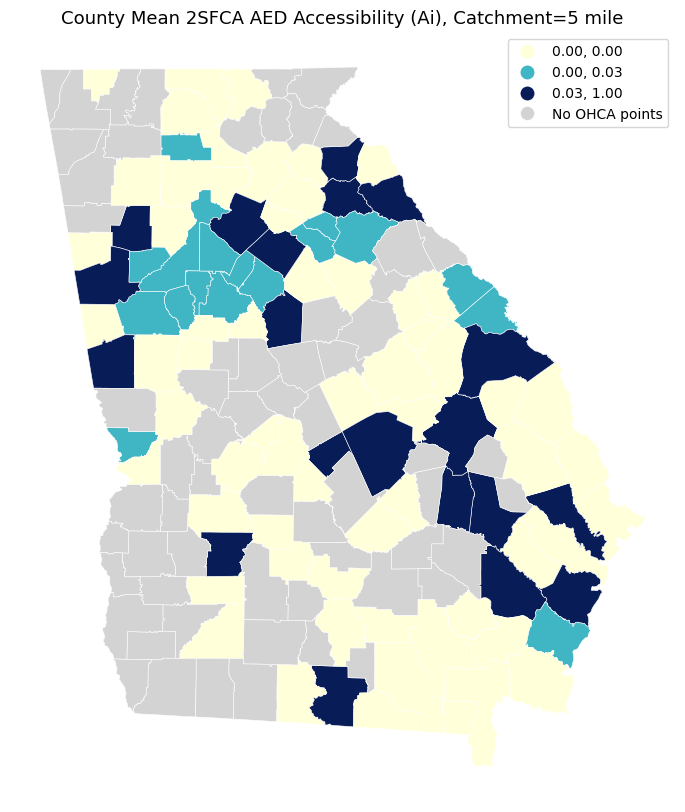

In [35]:
county_access_map = ga_counties.merge(county_access, on=['GEOID', 'NAME'], how='left')

fig, ax = plt.subplots(figsize=(10, 10))
county_access_map.plot(
    column='mean_Ai_2sfca',
    cmap='YlGnBu',
    scheme='quantiles',
    k=5,
    legend=True,
    linewidth=0.4,
    edgecolor='white',
    ax=ax,
    missing_kwds={'color': 'lightgray', 'label': 'No OHCA points'}
)
ax.set_title(f'County Mean 2SFCA AED Accessibility (Ai), Catchment={catchment_miles} mile', fontsize=13)
ax.axis('off')
plt.show()

## 11. Export Outputs

/opt/anaconda3/envs/ezr/lib/python3.10/site-packages/mapclassify/classifiers.py:1653: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 3.
  self.bins = quantile(y, k=k)


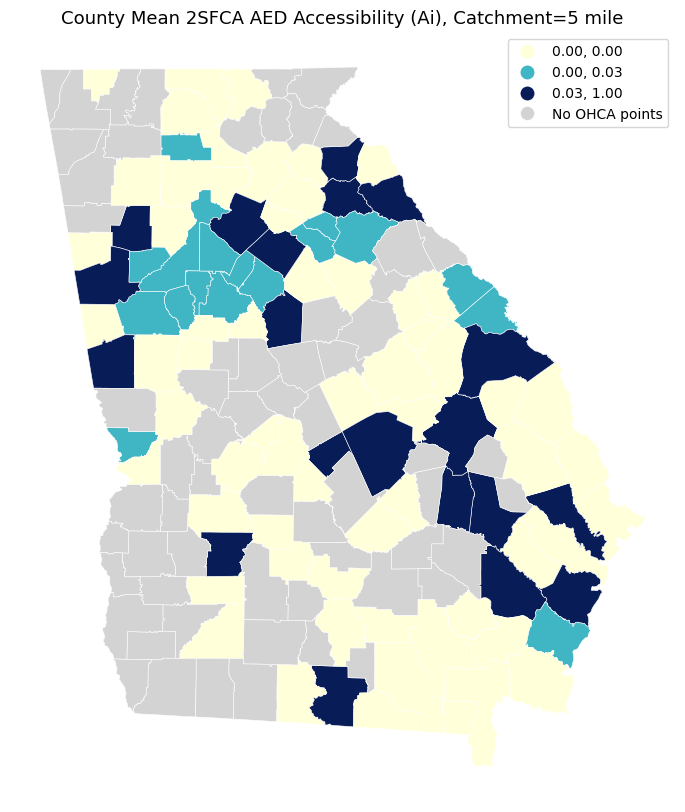

Saved AED points: /Users/jenny/Desktop/Workshop/data/outputs/simulated_aed_points_200.geojson
Saved event-level 2SFCA accessibility: /Users/jenny/Desktop/Workshop/data/outputs/ohca_event_2sfca_accessibility.csv
Saved county 2SFCA summary: /Users/jenny/Desktop/Workshop/data/outputs/county_2sfca_aed_accessibility_summary.csv
Saved 2SFCA map PNG: /Users/jenny/Desktop/Workshop/data/outputs/county_mean_2sfca_aed_accessibility_map.png


In [36]:
OUTPUT_DIR = DATA_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

aed_geojson = OUTPUT_DIR / 'simulated_aed_points_200.geojson'
event_csv = OUTPUT_DIR / 'ohca_event_2sfca_accessibility.csv'
county_csv = OUTPUT_DIR / 'county_2sfca_aed_accessibility_summary.csv'
map_png = OUTPUT_DIR / 'county_mean_2sfca_aed_accessibility_map.png'

# Export layers/tables
aed_gdf.to_file(aed_geojson, driver='GeoJSON')
ohca_ga_3857.to_crs('EPSG:4326').drop(columns='geometry').to_csv(event_csv, index=False)
county_access.to_csv(county_csv, index=False)

# Save map image
fig, ax = plt.subplots(figsize=(10, 10))
county_access_map.plot(
    column='mean_Ai_2sfca',
    cmap='YlGnBu',
    scheme='quantiles',
    k=5,
    legend=True,
    linewidth=0.4,
    edgecolor='white',
    ax=ax,
    missing_kwds={'color': 'lightgray', 'label': 'No OHCA points'}
)
ax.set_title(f'County Mean 2SFCA AED Accessibility (Ai), Catchment={catchment_miles} mile', fontsize=13)
ax.axis('off')
fig.savefig(map_png, dpi=300, bbox_inches='tight')
plt.show()

print('Saved AED points:', aed_geojson)
print('Saved event-level 2SFCA accessibility:', event_csv)
print('Saved county 2SFCA summary:', county_csv)
print('Saved 2SFCA map PNG:', map_png)

## Notes

- This notebook uses **simulated AED locations** for instruction only.
- For real studies, replace simulated AEDs with validated AED inventory data.
- 2SFCA explicitly combines **supply** (AED availability) and **demand** (OHCA events) in local catchments.
- `Ai` is a relative accessibility score: higher values indicate better accessibility under the same catchment assumptions.
- Test sensitivity by changing `catchment_miles` (for example: 0.5, 1.0, 2.0 miles).